In [1]:
import sys
import os
sys.path.append('/app/src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from utils.error_report import get_error_from_list
from data_loader import DataLoader
from configs.configs import MeasurementDataEnum, SetupEnum, ErrorEnum, FilterEnum, NoiseTypeEnum
from kalman_filters.extended_kalman_filter import ExtendedKalmanFilter
from kalman_filters.unscented_kalman_filter import UnscentedKalmanFilter
from kalman_filters.ensemble_kalman_filter import EnsembleKalmanFilter
from kalman_filters.particle_filter import ParticleFilter, ResamplingAlgorithms
from kalman_filters.cubature_kalman_filter import CubatureKalmanFilter


%matplotlib inline
np.random.seed(777)

# Load raw data 0016 (sequence number 04)

Data size: 271
Shape:
GPS: (271, 3)
VO: (271, 3)
IMU: (271, 6)
INS angle: (271, 3)
INS velocity: (271, 3)
Add noise to GPS data
Adding noise to VO data
Adding noise to IMU sensor data
Adding noise to linear acceleration
Adding noise to angular velocity
Adding noise to INS sensor data
Adding noise to linear velocity data
Adding noise to angle data
Data sampling is set to normal mode.


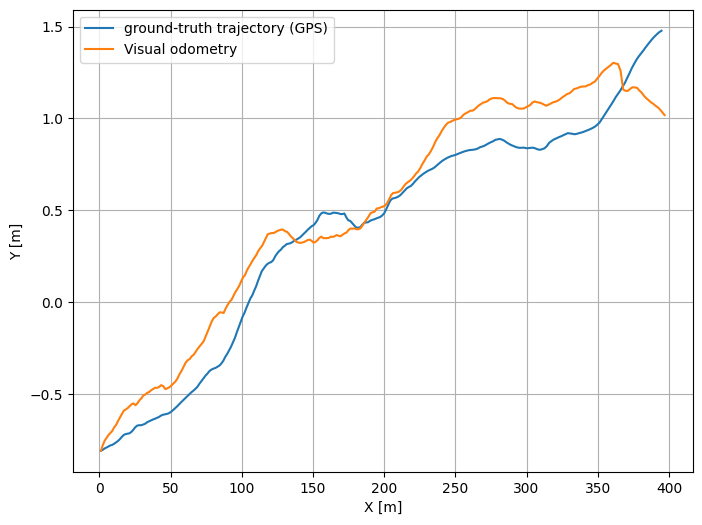

In [2]:
root_path = "../../../"
file_export_path = os.path.join(root_path, "exports/_sequences/04")
kitti_root_dir = os.path.join(root_path, "data")
noise_vector_dir = os.path.join(root_path, "exports/_noise_optimizations/noise_vectors")
kitti_date = '2011_09_30'
kitti_drive = '0016'
noise_type = NoiseTypeEnum.CURRENT

data = DataLoader(sequence_nr=kitti_drive, 
                  kitti_root_dir=kitti_root_dir, 
                  noise_vector_dir=noise_vector_dir,
                  vo_dropout_ratio=0.0, 
                  gps_dropout_ratio=0.0)

## Display data with noise

### VO trajectory with noise

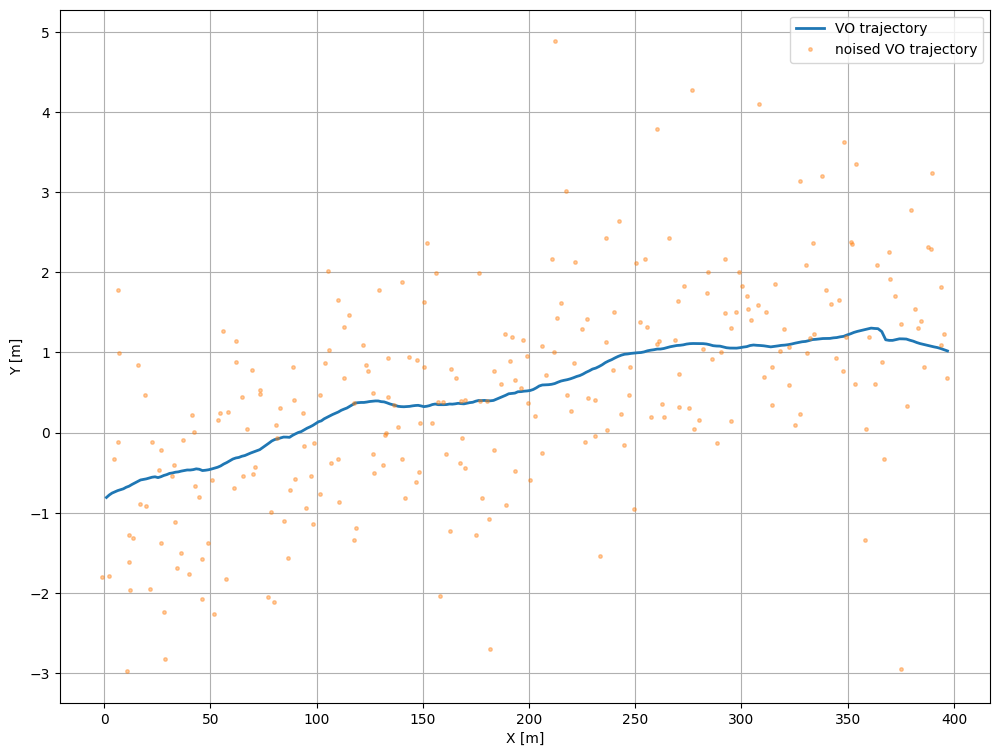

In [3]:
data.show_vo_with_noise()

### Linear acceleration with noise

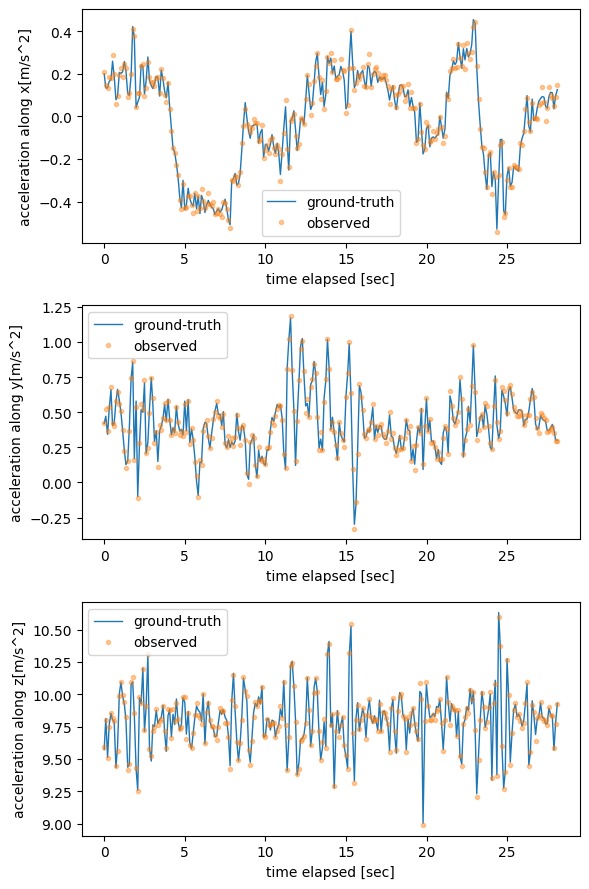

In [4]:
data.show_linear_acceleration_with_noise()

### Angular velocity with noise

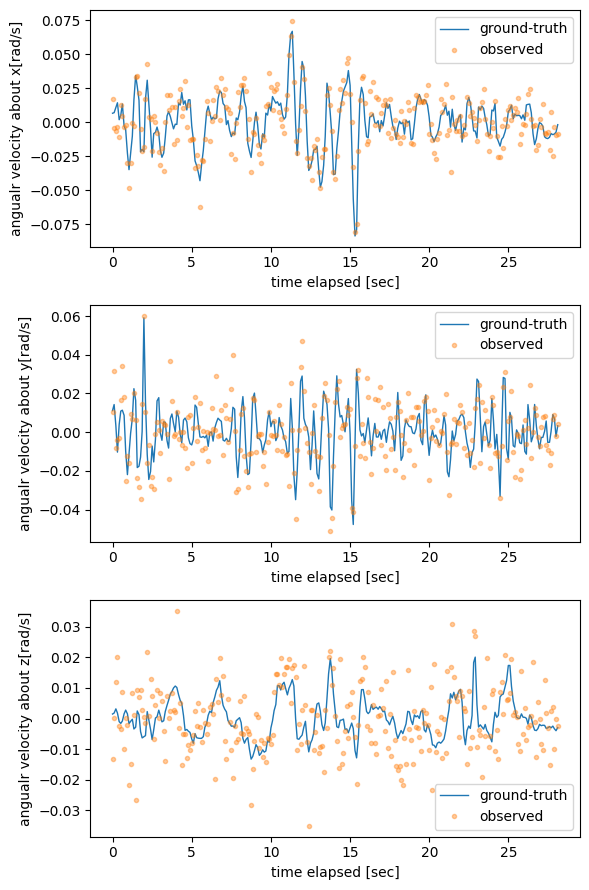

In [5]:
data.show_angular_velocity_with_noise()

### Linear velocity with noise

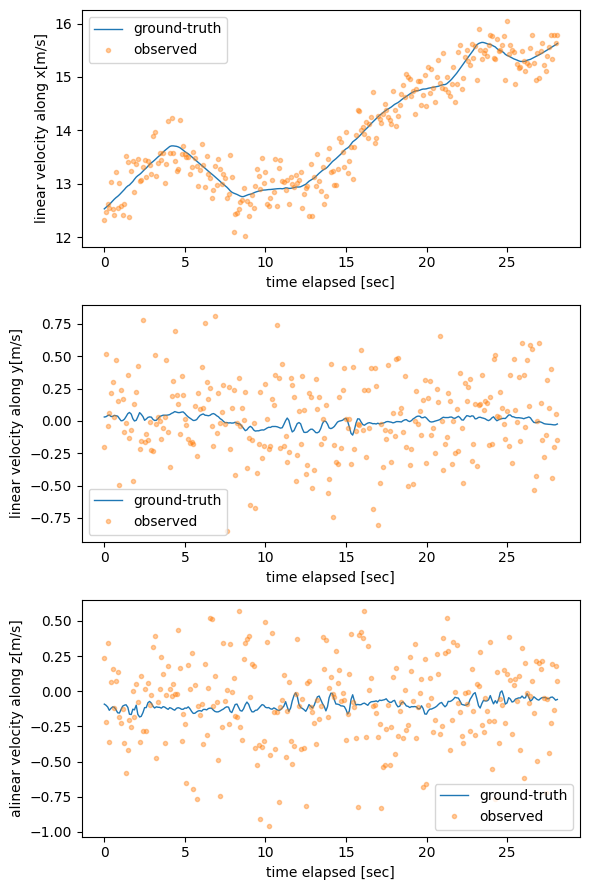

In [6]:
data.show_linear_velocity_with_noise()

# Applying filters

----

In [7]:
results_header = pd.MultiIndex.from_product([['Setup1 (IMU, VO)','Setup2(IMU, VO+GPS)', 'Setup3(INS, VO+INS)'],
                                             ['EKF', 'UKF', 'PF', 'EnKF', 'CKF']],
                                            names=['Setups','Filter types'])
df_dropout_indices = ['No dropout', '10% drop', '20% drop', '30% drop', '40% drop']

def get_error_dataframe(error_0, error_10, error_20, error_30, error_40):
    mae_0 = get_error_from_list(error_0, e_type=ErrorEnum.MAE)
    mae_10 = get_error_from_list(error_10, e_type=ErrorEnum.MAE)
    mae_20 = get_error_from_list(error_20, e_type=ErrorEnum.MAE)
    mae_30 = get_error_from_list(error_30, e_type=ErrorEnum.MAE)
    mae_40 = get_error_from_list(error_40, e_type=ErrorEnum.MAE)

    rmse_0 = get_error_from_list(error_0, e_type=ErrorEnum.RMSE)
    rmse_10 = get_error_from_list(error_10, e_type=ErrorEnum.RMSE)
    rmse_20 = get_error_from_list(error_20, e_type=ErrorEnum.RMSE)
    rmse_30 = get_error_from_list(error_30, e_type=ErrorEnum.RMSE)
    rmse_40 = get_error_from_list(error_40, e_type=ErrorEnum.RMSE)
    
    max_0 = get_error_from_list(error_0, e_type=ErrorEnum.MAX)
    max_10 = get_error_from_list(error_10, e_type=ErrorEnum.MAX)
    max_20 = get_error_from_list(error_20, e_type=ErrorEnum.MAX)
    max_30 = get_error_from_list(error_30, e_type=ErrorEnum.MAX)
    max_40 = get_error_from_list(error_40, e_type=ErrorEnum.MAX)
    
    mae_error = [mae_0, mae_10, mae_20, mae_30, mae_40]
    rmse_error = [rmse_0, rmse_10, rmse_20, rmse_30, rmse_40]
    max_error = [max_0, max_10, max_20, max_30, max_40]
    
    mae_df = pd.DataFrame(np.array(mae_error), 
                            index=df_dropout_indices, 
                            columns=results_header)
    rmse_df = pd.DataFrame(np.array(rmse_error), 
                            index=df_dropout_indices, 
                            columns=results_header)
    max_df = pd.DataFrame(np.array(max_error), 
                            index=df_dropout_indices, 
                            columns=results_header)
    
    return mae_df, rmse_df, max_df



In [8]:
errors_0 = []
errors_10 = []
errors_20 = []
errors_30 = []
errors_40 = []

# No measurement data drop

In [9]:
data.change_dropout_ratio(vo_dropout_ratio=0.0, gps_dropout_ratio=0.0)

In [10]:
alpha_setup1_0 = 0.1
beta_setup1_0 = 2.0
kappa_setup1_0 = 0.0

alpha_setup2_0 = 1.0
beta_setup2_0 = 2.0
kappa_setup2_0 = 0.0

alpha_setup3_0 = 0.001
beta_setup3_0 = 2.0
kappa_setup3_0 = 0.0

n_samples_setup1_0 = 2048
resampling_algorithm_setup1_0 = ResamplingAlgorithms.RESIDUAL
n_samples_setup2_0 = 2048
resampling_algorithm_setup2_0 = ResamplingAlgorithms.SYSTEMATIC
n_samples_setup3_0 = 2048
resampling_algorithm_setup3_0 = ResamplingAlgorithms.MULTINOMIAL
importance_resampling = True

n_ensemble_setup1_0 = 1024
n_ensemble_setup2_0 = 1024
n_ensemble_setup3_0 = 1024

## Setup1

In [11]:
setup = SetupEnum.SETUP_1

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EKF, 
  noise_type=noise_type)
ekf1_0 = ExtendedKalmanFilter(
  x=x_setup1.copy(), 
  P=P_setup1.copy(), 
  H=H_setup1.copy(),
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  setup=setup
)

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.UKF, 
  noise_type=noise_type)
ukf1_0 = UnscentedKalmanFilter(
  x=x_setup1.copy(), 
  P=P_setup1.copy(), 
  H=H_setup1.copy(), 
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  alpha=alpha_setup1_0, 
  beta=beta_setup1_0, 
  kappa=kappa_setup1_0,
  setup=setup
)

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.PF, 
  noise_type=noise_type)
pf1_0 = ParticleFilter(
  N=n_samples_setup1_0, 
  x_dim=x_setup1.shape[0], 
  H=H_setup1.copy(), 
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  setup=setup,
  resampling_algorithm=resampling_algorithm_setup1_0
)
pf1_0.create_gaussian_particles(mean=x_setup1.copy(), var=P_setup1.copy())

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EnKF, 
  noise_type=noise_type)
enkf1_0 = EnsembleKalmanFilter(
  N=n_ensemble_setup1_0, 
  x=x_setup1.copy(), 
  P=P_setup1.copy(), 
  H=H_setup1.copy(),
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  setup=setup
)

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.CKF, 
  noise_type=noise_type)
ckf1_0 = CubatureKalmanFilter(
    x=x_setup1.copy(), 
    P=P_setup1.copy(), 
    H=H_setup1.copy(),
    q=q1,
    r_vo=r_vo1,
    r_gps=r_gps1,
    setup=setup,
)

In [12]:
error_ekf1_0 = ekf1_0.run(data=data, debug_mode=True)
error_ukf1_0 = ukf1_0.run(data=data, debug_mode=True)
error_pf1_0 = pf1_0.run(data=data, debug_mode=True, importance_resampling=importance_resampling)
error_enkf1_0 = enkf1_0.run(data=data, debug_mode=True)
error_ckf1_0 = ckf1_0.run(data=data, debug_mode=True)


errors_0.append(error_ekf1_0)
errors_0.append(error_ukf1_0)
errors_0.append(error_pf1_0)
errors_0.append(error_enkf1_0)
errors_0.append(error_ckf1_0)

[EKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 9265.09it/s]



----- [EKF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 0.726 m
Root Mean Squared Error: 0.976 m
Maximum Error: 3.631 m
---------------------------------------------------

[UKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 2269.73it/s]



----- [UKF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 0.872 m
Root Mean Squared Error: 1.148 m
Maximum Error: 4.154 m
---------------------------------------------------

[PF] start.


...


----- [PF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 119.641 m
Root Mean Squared Error: 177.71 m
Maximum Error: 598.789 m
--------------------------------------------------

[EnKF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:02<00:00, 90.67it/s]



----- [EnKF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 1.188 m
Root Mean Squared Error: 1.517 m
Maximum Error: 5.966 m
----------------------------------------------------

[CKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 2818.63it/s]


----- [CKF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 0.746 m
Root Mean Squared Error: 0.969 m
Maximum Error: 3.75 m
---------------------------------------------------



## Setup2

In [13]:
setup = SetupEnum.SETUP_2

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EKF, 
  noise_type=noise_type)
ekf2_0 = ExtendedKalmanFilter(
  x=x_setup2.copy(), 
  P=P_setup2.copy(), 
  H=H_setup2.copy(),
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup
)

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.UKF, 
  noise_type=noise_type)
ukf2_0 = UnscentedKalmanFilter(
    x=x_setup2.copy(), 
    P=P_setup2.copy(), 
    H=H_setup2.copy(), 
    q=q2,
    r_vo=r_vo2,
    r_gps=r_gps2,
    alpha=alpha_setup2_0, 
    beta=beta_setup2_0, 
    kappa=kappa_setup2_0,
    setup=setup
)

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.PF, 
  noise_type=noise_type)
pf2_0 = ParticleFilter(
  N=n_samples_setup2_0, 
  x_dim=x_setup2.shape[0], 
  H=H_setup2.copy(), 
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup,
  resampling_algorithm=resampling_algorithm_setup2_0
)
pf2_0.create_gaussian_particles(mean=x_setup2.copy(), var=P_setup2.copy())

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EnKF, 
  noise_type=noise_type)
enkf2_0 = EnsembleKalmanFilter(
  N=n_ensemble_setup2_0, 
  x=x_setup2.copy(), 
  P=P_setup2.copy(), 
  H=H_setup2.copy(),
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup
)

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.CKF, 
  noise_type=noise_type)
ckf2_0 = CubatureKalmanFilter(
  x=x_setup2.copy(), 
  P=P_setup2.copy(), 
  H=H_setup2.copy(),
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup,
)

In [14]:
error_ekf2_0 = ekf2_0.run(data=data, debug_mode=True)
error_ukf2_0 = ukf2_0.run(data=data, debug_mode=True)
error_pf2_0 = pf2_0.run(data=data, debug_mode=True, importance_resampling=importance_resampling)
error_enkf2_0 = enkf2_0.run(data=data, debug_mode=True)
error_ckf2_0 = ckf2_0.run(data=data, debug_mode=True)

errors_0.append(error_ekf2_0)
errors_0.append(error_ukf2_0)
errors_0.append(error_pf2_0)
errors_0.append(error_enkf2_0)
errors_0.append(error_ckf2_0)

[EKF] start.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 10037.69it/s]



----- [EKF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 0.515 m
Root Mean Squared Error: 0.679 m
Maximum Error: 3.02 m
-------------------------------------------------------

[UKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 2164.74it/s]



----- [UKF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 0.657 m
Root Mean Squared Error: 0.836 m
Maximum Error: 3.315 m
-------------------------------------------------------

[PF] start.


...


----- [PF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 163.181 m
Root Mean Squared Error: 237.902 m
Maximum Error: 764.408 m
------------------------------------------------------

[EnKF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:03<00:00, 67.72it/s]



----- [EnKF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 1.03 m
Root Mean Squared Error: 1.295 m
Maximum Error: 4.76 m
--------------------------------------------------------

[CKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 2203.33it/s]


----- [CKF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 0.609 m
Root Mean Squared Error: 0.783 m
Maximum Error: 3.865 m
-------------------------------------------------------



## Setup3

In [15]:
setup = SetupEnum.SETUP_3

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EKF, 
  noise_type=noise_type)
ekf3_0 = ExtendedKalmanFilter(
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(),
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
)

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.UKF, 
  noise_type=noise_type)
ukf3_0 = UnscentedKalmanFilter(
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(), 
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  alpha=alpha_setup3_0, 
  beta=beta_setup3_0, 
  kappa=kappa_setup3_0,
  setup=setup,
)

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.PF, 
  noise_type=noise_type)
pf3_0 = ParticleFilter(
  N=n_samples_setup3_0, 
  x_dim=x_setup3.shape[0], 
  H=H_setup3.copy(), 
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
  resampling_algorithm=resampling_algorithm_setup3_0
)
pf3_0.create_gaussian_particles(mean=x_setup3.copy(), var=P_setup3.copy())

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EnKF, 
  noise_type=noise_type)
enkf3_0 = EnsembleKalmanFilter(
  N=n_ensemble_setup3_0, 
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(),
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
)

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.CKF, 
  noise_type=noise_type)
ckf3_0 = CubatureKalmanFilter(
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(),
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
)

In [16]:
error_ekf3_0 = ekf3_0.run(data=data, debug_mode=True)
error_ukf3_0 = ukf3_0.run(data=data, debug_mode=True)
error_pf3_0 = pf3_0.run(data=data, debug_mode=True, importance_resampling=importance_resampling)
error_enkf3_0 = enkf3_0.run(data=data, debug_mode=True)
error_ckf3_0 = ckf3_0.run(data=data, debug_mode=True)

errors_0.append(error_ekf3_0)
errors_0.append(error_ukf3_0)
errors_0.append(error_pf3_0)
errors_0.append(error_enkf3_0)
errors_0.append(error_ckf3_0)

[EKF] start.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 20681.97it/s]



----- [EKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 0.383 m
Root Mean Squared Error: 0.503 m
Maximum Error: 1.614 m
-----------------------------------------------

[UKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 7125.32it/s]



----- [UKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 0.521 m
Root Mean Squared Error: 0.671 m
Maximum Error: 2.944 m
-----------------------------------------------

[PF] start.


...


----- [PF] Error report for Setup3 (INS) -----
Mean Absolute Error: 0.352 m
Root Mean Squared Error: 0.49 m
Maximum Error: 1.862 m
----------------------------------------------

[EnKF] start.


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:01<00:00, 137.07it/s]



----- [EnKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 0.947 m
Root Mean Squared Error: 1.21 m
Maximum Error: 3.459 m
------------------------------------------------

[CKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 7223.53it/s]


----- [CKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 0.521 m
Root Mean Squared Error: 0.671 m
Maximum Error: 2.941 m
-----------------------------------------------



# 10% drop

In [17]:
data.change_dropout_ratio(vo_dropout_ratio=0.1, gps_dropout_ratio=0.1)

In [18]:
alpha_setup1_10 = 1.0
beta_setup1_10 = 2.0
kappa_setup1_10 = 0.0

alpha_setup2_10 = 1.0
beta_setup2_10 = 2.0
kappa_setup2_10 = 0.0

alpha_setup3_10 = 0.001
beta_setup3_10 = 2.0
kappa_setup3_10 = 0.0

n_samples_setup1_10 = 2048
resampling_algorithm_setup1_10 = ResamplingAlgorithms.SYSTEMATIC
n_samples_setup2_10 = 2048
resampling_algorithm_setup2_10 = ResamplingAlgorithms.SYSTEMATIC
n_samples_setup3_10 = 2048
resampling_algorithm_setup3_10 = ResamplingAlgorithms.MULTINOMIAL

n_ensemble_setup1_10 = 1024
n_ensemble_setup2_10 = 1024
n_ensemble_setup3_10 = 1024

## Setup1

In [19]:
setup = SetupEnum.SETUP_1

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EKF, 
  noise_type=noise_type)
ekf1_10 = ExtendedKalmanFilter(
  x=x_setup1.copy(), 
  P=P_setup1.copy(), 
  H=H_setup1.copy(),
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  setup=setup
)

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.UKF, 
  noise_type=noise_type)
ukf1_10 = UnscentedKalmanFilter(
  x=x_setup1.copy(), 
  P=P_setup1.copy(), 
  H=H_setup1.copy(), 
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  alpha=alpha_setup1_10, 
  beta=beta_setup1_10, 
  kappa=kappa_setup1_10,
  setup=setup
)

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.PF, 
  noise_type=noise_type)
pf1_10 = ParticleFilter(
  N=n_samples_setup1_10, 
  x_dim=x_setup1.shape[0], 
  H=H_setup1.copy(), 
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  setup=setup,
  resampling_algorithm=resampling_algorithm_setup1_10
)
pf1_10.create_gaussian_particles(mean=x_setup1.copy(), var=P_setup1.copy())

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EnKF, 
  noise_type=noise_type)
enkf1_10 = EnsembleKalmanFilter(
  N=n_ensemble_setup1_10, 
  x=x_setup1.copy(), 
  P=P_setup1.copy(), 
  H=H_setup1.copy(),
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  setup=setup
)

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.CKF, 
  noise_type=noise_type)
ckf1_10 = CubatureKalmanFilter(
    x=x_setup1.copy(), 
    P=P_setup1.copy(), 
    H=H_setup1.copy(),
    q=q1,
    r_vo=r_vo1,
    r_gps=r_gps1,
    setup=setup,
)

In [20]:
error_ekf1_10 = ekf1_10.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ukf1_10 = ukf1_10.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_pf1_10 = pf1_10.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    importance_resampling=importance_resampling,
    debug_mode=True
)
error_enkf1_10 = enkf1_10.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ckf1_10 = ckf1_10.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT, 
    debug_mode=True,
)

errors_10.append(error_ekf1_10)
errors_10.append(error_ukf1_10)
errors_10.append(error_pf1_10)
errors_10.append(error_enkf1_10)
errors_10.append(error_ckf1_10)

[EKF] start.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 12668.21it/s]



----- [EKF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 0.772 m
Root Mean Squared Error: 1.035 m
Maximum Error: 3.809 m
---------------------------------------------------

[UKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 2869.81it/s]



----- [UKF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 1.585 m
Root Mean Squared Error: 2.043 m
Maximum Error: 7.892 m
---------------------------------------------------

[PF] start.


...


----- [PF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 109.939 m
Root Mean Squared Error: 172.539 m
Maximum Error: 524.354 m
--------------------------------------------------

[EnKF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:02<00:00, 92.31it/s]



----- [EnKF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 1.226 m
Root Mean Squared Error: 1.571 m
Maximum Error: 5.86 m
----------------------------------------------------

[CKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 3032.61it/s]


----- [CKF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 0.766 m
Root Mean Squared Error: 1.01 m
Maximum Error: 3.743 m
---------------------------------------------------



## Setup2

In [21]:
setup = SetupEnum.SETUP_2

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EKF, 
  noise_type=noise_type)
ekf2_10 = ExtendedKalmanFilter(
  x=x_setup2.copy(), 
  P=P_setup2.copy(), 
  H=H_setup2.copy(),
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup
)

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.UKF, 
  noise_type=noise_type)
ukf2_10 = UnscentedKalmanFilter(
    x=x_setup2.copy(), 
    P=P_setup2.copy(), 
    H=H_setup2.copy(), 
    q=q2,
    r_vo=r_vo2,
    r_gps=r_gps2,
    alpha=alpha_setup2_10, 
    beta=beta_setup2_10, 
    kappa=kappa_setup2_10,
    setup=setup
)

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.PF, 
  noise_type=noise_type)
pf2_10 = ParticleFilter(
  N=n_samples_setup2_10, 
  x_dim=x_setup2.shape[0], 
  H=H_setup2.copy(), 
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup,
  resampling_algorithm=resampling_algorithm_setup2_10
)
pf2_10.create_gaussian_particles(mean=x_setup2.copy(), var=P_setup2.copy())

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EnKF, 
  noise_type=noise_type)
enkf2_10 = EnsembleKalmanFilter(
  N=n_ensemble_setup2_10, 
  x=x_setup2.copy(), 
  P=P_setup2.copy(), 
  H=H_setup2.copy(),
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup
)

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.CKF, 
  noise_type=noise_type)
ckf2_10 = CubatureKalmanFilter(
  x=x_setup2.copy(), 
  P=P_setup2.copy(), 
  H=H_setup2.copy(),
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup,
)

In [22]:
error_ekf2_10 = ekf2_10.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ukf2_10 = ukf2_10.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_pf2_10 = pf2_10.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    importance_resampling=importance_resampling,
    debug_mode=True
)
error_enkf2_10 = enkf2_10.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ckf2_10 = ckf2_10.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT, 
    debug_mode=True
)

errors_10.append(error_ekf2_10)
errors_10.append(error_ukf2_10)
errors_10.append(error_pf2_10)
errors_10.append(error_enkf2_10)
errors_10.append(error_ckf2_10)

[EKF] start.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 10299.51it/s]



----- [EKF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 0.536 m
Root Mean Squared Error: 0.71 m
Maximum Error: 3.54 m
-------------------------------------------------------

[UKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 2211.62it/s]



----- [UKF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 0.683 m
Root Mean Squared Error: 0.855 m
Maximum Error: 2.841 m
-------------------------------------------------------

[PF] start.


...


----- [PF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 0.795 m
Root Mean Squared Error: 1.193 m
Maximum Error: 5.861 m
------------------------------------------------------

[EnKF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:03<00:00, 70.35it/s]



----- [EnKF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 1.052 m
Root Mean Squared Error: 1.336 m
Maximum Error: 6.376 m
--------------------------------------------------------

[CKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 2398.74it/s]


----- [CKF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 0.617 m
Root Mean Squared Error: 0.792 m
Maximum Error: 3.476 m
-------------------------------------------------------



## Setup3

In [23]:
setup = SetupEnum.SETUP_3

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EKF, 
  noise_type=noise_type)
ekf3_10 = ExtendedKalmanFilter(
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(),
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
)

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.UKF, 
  noise_type=noise_type)
ukf3_10 = UnscentedKalmanFilter(
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(), 
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  alpha=alpha_setup3_10, 
  beta=beta_setup3_10, 
  kappa=kappa_setup3_10,
  setup=setup,
)

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.PF, 
  noise_type=noise_type)
pf3_10 = ParticleFilter(
  N=n_samples_setup3_10, 
  x_dim=x_setup3.shape[0], 
  H=H_setup3.copy(), 
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
  resampling_algorithm=resampling_algorithm_setup3_10
)
pf3_10.create_gaussian_particles(mean=x_setup3.copy(), var=P_setup3.copy())

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EnKF, 
  noise_type=noise_type)
enkf3_10 = EnsembleKalmanFilter(
  N=n_ensemble_setup3_10, 
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(),
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
)

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.CKF, 
  noise_type=noise_type)
ckf3_10 = CubatureKalmanFilter(
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(),
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
)

In [24]:
error_ekf3_10 = ekf3_10.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ukf3_10 = ukf3_10.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_pf3_10 = pf3_10.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    importance_resampling=importance_resampling,
    debug_mode=True
)
error_enkf3_10 = enkf3_10.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ckf3_10 = ckf3_10.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT, 
    debug_mode=True
)


errors_10.append(error_ekf3_10)
errors_10.append(error_ukf3_10)
errors_10.append(error_pf3_10)
errors_10.append(error_enkf3_10)
errors_10.append(error_ckf3_10)

[EKF] start.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 16968.01it/s]



----- [EKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 0.383 m
Root Mean Squared Error: 0.506 m
Maximum Error: 1.617 m
-----------------------------------------------

[UKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 7587.79it/s]



----- [UKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 0.524 m
Root Mean Squared Error: 0.675 m
Maximum Error: 2.582 m
-----------------------------------------------

[PF] start.


...


----- [PF] Error report for Setup3 (INS) -----
Mean Absolute Error: 0.383 m
Root Mean Squared Error: 0.512 m
Maximum Error: 1.885 m
----------------------------------------------

[EnKF] start.


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:01<00:00, 152.25it/s]



----- [EnKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 0.978 m
Root Mean Squared Error: 1.244 m
Maximum Error: 4.468 m
------------------------------------------------

[CKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 7881.01it/s]


----- [CKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 0.524 m
Root Mean Squared Error: 0.675 m
Maximum Error: 2.579 m
-----------------------------------------------



# 20% drop

In [25]:
data.change_dropout_ratio(vo_dropout_ratio=0.2, gps_dropout_ratio=0.2)

In [26]:
alpha_setup1_20 = 1.0
beta_setup1_20 = 2.0
kappa_setup1_20 = 0.0

alpha_setup2_20 = 1.0
beta_setup2_20 = 2.0
kappa_setup2_20 = 0.0

alpha_setup3_20 = 0.001
beta_setup3_20 = 2.0
kappa_setup3_20 = 0.0

n_samples_setup1_20 = 2048
resampling_algorithm_setup1_20 = ResamplingAlgorithms.SYSTEMATIC
n_samples_setup2_20 = 2048
resampling_algorithm_setup2_20 = ResamplingAlgorithms.SYSTEMATIC
n_samples_setup3_20 = 2048
resampling_algorithm_setup3_20 = ResamplingAlgorithms.MULTINOMIAL

n_ensemble_setup1_20 = 1024
n_ensemble_setup2_20 = 1024
n_ensemble_setup3_20 = 1024

## Setup1

In [27]:
setup = SetupEnum.SETUP_1

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EKF, 
  noise_type=noise_type)
ekf1_20 = ExtendedKalmanFilter(
  x=x_setup1.copy(), 
  P=P_setup1.copy(), 
  H=H_setup1.copy(),
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  setup=setup
)

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.UKF, 
  noise_type=noise_type)
ukf1_20 = UnscentedKalmanFilter(
  x=x_setup1.copy(), 
  P=P_setup1.copy(), 
  H=H_setup1.copy(), 
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  alpha=alpha_setup1_20, 
  beta=beta_setup1_20, 
  kappa=kappa_setup1_20,
  setup=setup
)

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.PF, 
  noise_type=noise_type)
pf1_20 = ParticleFilter(
  N=n_samples_setup1_20, 
  x_dim=x_setup1.shape[0], 
  H=H_setup1.copy(), 
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  setup=setup,
  resampling_algorithm=resampling_algorithm_setup1_20
)
pf1_20.create_gaussian_particles(mean=x_setup1.copy(), var=P_setup1.copy())

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EnKF, 
  noise_type=noise_type)
enkf1_20 = EnsembleKalmanFilter(
  N=n_ensemble_setup1_20, 
  x=x_setup1.copy(), 
  P=P_setup1.copy(), 
  H=H_setup1.copy(),
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  setup=setup
)

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.CKF, 
  noise_type=noise_type)
ckf1_20 = CubatureKalmanFilter(
    x=x_setup1.copy(), 
    P=P_setup1.copy(), 
    H=H_setup1.copy(),
    q=q1,
    r_vo=r_vo1,
    r_gps=r_gps1,
    setup=setup,
)

In [28]:
error_ekf1_20 = ekf1_20.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ukf1_20 = ukf1_20.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_pf1_20 = pf1_20.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    importance_resampling=importance_resampling,
    debug_mode=True
)
error_enkf1_20 = enkf1_20.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ckf1_20 = ckf1_20.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT, 
    debug_mode=True,
)

errors_20.append(error_ekf1_20)
errors_20.append(error_ukf1_20)
errors_20.append(error_pf1_20)
errors_20.append(error_enkf1_20)
errors_20.append(error_ckf1_20)

[EKF] start.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 12526.27it/s]



----- [EKF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 0.828 m
Root Mean Squared Error: 1.08 m
Maximum Error: 4.058 m
---------------------------------------------------

[UKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 3004.24it/s]



----- [UKF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 1.493 m
Root Mean Squared Error: 1.944 m
Maximum Error: 7.671 m
---------------------------------------------------

[PF] start.


...


----- [PF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 149.597 m
Root Mean Squared Error: 208.055 m
Maximum Error: 538.508 m
--------------------------------------------------

[EnKF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:02<00:00, 92.72it/s]



----- [EnKF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 1.251 m
Root Mean Squared Error: 1.617 m
Maximum Error: 6.108 m
----------------------------------------------------

[CKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 3018.24it/s]


----- [CKF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 0.776 m
Root Mean Squared Error: 1.014 m
Maximum Error: 3.687 m
---------------------------------------------------



## Setup2

In [29]:
setup = SetupEnum.SETUP_2

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EKF, 
  noise_type=noise_type)
ekf2_20 = ExtendedKalmanFilter(
  x=x_setup2.copy(), 
  P=P_setup2.copy(), 
  H=H_setup2.copy(),
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup
)

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.UKF, 
  noise_type=noise_type)
ukf2_20 = UnscentedKalmanFilter(
    x=x_setup2.copy(), 
    P=P_setup2.copy(), 
    H=H_setup2.copy(), 
    q=q2,
    r_vo=r_vo2,
    r_gps=r_gps2,
    alpha=alpha_setup2_20, 
    beta=beta_setup2_20, 
    kappa=kappa_setup2_20,
    setup=setup
)

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.PF, 
  noise_type=noise_type)
pf2_20 = ParticleFilter(
  N=n_samples_setup2_20, 
  x_dim=x_setup2.shape[0], 
  H=H_setup2.copy(), 
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup,
  resampling_algorithm=resampling_algorithm_setup2_20
)
pf2_20.create_gaussian_particles(mean=x_setup2.copy(), var=P_setup2.copy())

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EnKF, 
  noise_type=noise_type)
enkf2_20 = EnsembleKalmanFilter(
  N=n_ensemble_setup2_20, 
  x=x_setup2.copy(), 
  P=P_setup2.copy(), 
  H=H_setup2.copy(),
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup
)

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.CKF, 
  noise_type=noise_type)
ckf2_20 = CubatureKalmanFilter(
  x=x_setup2.copy(), 
  P=P_setup2.copy(), 
  H=H_setup2.copy(),
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup,
)

In [30]:
error_ekf2_20 = ekf2_20.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ukf2_20 = ukf2_20.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_pf2_20 = pf2_20.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT,
    importance_resampling=importance_resampling,
    debug_mode=True
)
error_enkf2_20 = enkf2_20.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ckf2_20 = ckf2_20.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT, 
    debug_mode=True
)

errors_20.append(error_ekf2_20)
errors_20.append(error_ukf2_20)
errors_20.append(error_pf2_20)
errors_20.append(error_enkf2_20)
errors_20.append(error_ckf2_20)

[EKF] start.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 10844.22it/s]



----- [EKF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 0.548 m
Root Mean Squared Error: 0.72 m
Maximum Error: 3.54 m
-------------------------------------------------------

[UKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 2277.63it/s]



----- [UKF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 0.757 m
Root Mean Squared Error: 0.994 m
Maximum Error: 4.501 m
-------------------------------------------------------

[PF] start.


...


----- [PF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 0.789 m
Root Mean Squared Error: 1.243 m
Maximum Error: 6.438 m
------------------------------------------------------

[EnKF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:03<00:00, 72.66it/s]



----- [EnKF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 1.064 m
Root Mean Squared Error: 1.366 m
Maximum Error: 4.427 m
--------------------------------------------------------

[CKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 2442.71it/s]


----- [CKF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 0.63 m
Root Mean Squared Error: 0.812 m
Maximum Error: 3.755 m
-------------------------------------------------------



## Setup3

In [31]:
setup = SetupEnum.SETUP_3

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EKF, 
  noise_type=noise_type)
ekf3_20 = ExtendedKalmanFilter(
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(),
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
)

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.UKF, 
  noise_type=noise_type)
ukf3_20 = UnscentedKalmanFilter(
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(), 
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  alpha=alpha_setup3_20, 
  beta=beta_setup3_20, 
  kappa=kappa_setup3_20,
  setup=setup,
)

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.PF, 
  noise_type=noise_type)
pf3_20 = ParticleFilter(
  N=n_samples_setup3_20, 
  x_dim=x_setup3.shape[0], 
  H=H_setup3.copy(), 
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
  resampling_algorithm=resampling_algorithm_setup3_20
)
pf3_20.create_gaussian_particles(mean=x_setup3.copy(), var=P_setup3.copy())

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EnKF, 
  noise_type=noise_type)
enkf3_20 = EnsembleKalmanFilter(
  N=n_ensemble_setup3_20, 
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(),
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
)

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.CKF, 
  noise_type=noise_type)
ckf3_20 = CubatureKalmanFilter(
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(),
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
)

In [32]:
error_ekf3_20 = ekf3_20.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ukf3_20 = ukf3_20.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_pf3_20 = pf3_20.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    importance_resampling=importance_resampling,
    debug_mode=True
)
error_enkf3_20 = enkf3_20.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ckf3_20 = ckf3_20.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT, 
    debug_mode=True
)


errors_20.append(error_ekf3_20)
errors_20.append(error_ukf3_20)
errors_20.append(error_pf3_20)
errors_20.append(error_enkf3_20)
errors_20.append(error_ckf3_20)

[EKF] start.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 20522.68it/s]



----- [EKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 0.423 m
Root Mean Squared Error: 0.552 m
Maximum Error: 1.815 m
-----------------------------------------------

[UKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 7909.58it/s]



----- [UKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 0.541 m
Root Mean Squared Error: 0.698 m
Maximum Error: 3.03 m
-----------------------------------------------

[PF] start.


...


----- [PF] Error report for Setup3 (INS) -----
Mean Absolute Error: 0.385 m
Root Mean Squared Error: 0.52 m
Maximum Error: 2.372 m
----------------------------------------------

[EnKF] start.


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:01<00:00, 166.72it/s]



----- [EnKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 0.972 m
Root Mean Squared Error: 1.248 m
Maximum Error: 4.418 m
------------------------------------------------

[CKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 6744.62it/s]


----- [CKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 0.541 m
Root Mean Squared Error: 0.698 m
Maximum Error: 3.027 m
-----------------------------------------------



# 30% drop

In [33]:
data.change_dropout_ratio(vo_dropout_ratio=0.3, gps_dropout_ratio=0.3)

In [34]:
alpha_setup1_30 = 1.0
beta_setup1_30 = 2.0
kappa_setup1_30 = 0.0

alpha_setup2_30 = 1.0
beta_setup2_30 = 2.0
kappa_setup2_30 = 0.0

alpha_setup3_30 = 0.001
beta_setup3_30 = 2.0
kappa_setup3_30 = 0.0

n_samples_setup1_30 = 2048
resampling_algorithm_setup1_30 = ResamplingAlgorithms.SYSTEMATIC
n_samples_setup2_30 = 2048
resampling_algorithm_setup2_30 = ResamplingAlgorithms.SYSTEMATIC
n_samples_setup3_30 = 2048
resampling_algorithm_setup3_30 = ResamplingAlgorithms.MULTINOMIAL

n_ensemble_setup1_30 = 1024
n_ensemble_setup2_30 = 1024
n_ensemble_setup3_30 = 1024

## Setup1

In [35]:
setup = SetupEnum.SETUP_1

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EKF, 
  noise_type=noise_type)
ekf1_30 = ExtendedKalmanFilter(
  x=x_setup1.copy(), 
  P=P_setup1.copy(), 
  H=H_setup1.copy(),
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  setup=setup
)

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.UKF, 
  noise_type=noise_type)
ukf1_30 = UnscentedKalmanFilter(
  x=x_setup1.copy(), 
  P=P_setup1.copy(), 
  H=H_setup1.copy(), 
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  alpha=alpha_setup1_30, 
  beta=beta_setup1_30, 
  kappa=kappa_setup1_30,
  setup=setup
)

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.PF, 
  noise_type=noise_type)
pf1_30 = ParticleFilter(
  N=n_samples_setup1_30, 
  x_dim=x_setup1.shape[0], 
  H=H_setup1.copy(), 
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  setup=setup,
  resampling_algorithm=resampling_algorithm_setup1_30
)
pf1_30.create_gaussian_particles(mean=x_setup1.copy(), var=P_setup1.copy())

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EnKF, 
  noise_type=noise_type)
enkf1_30 = EnsembleKalmanFilter(
  N=n_ensemble_setup1_30, 
  x=x_setup1.copy(), 
  P=P_setup1.copy(), 
  H=H_setup1.copy(),
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  setup=setup
)

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.CKF, 
  noise_type=noise_type)
ckf1_30 = CubatureKalmanFilter(
    x=x_setup1.copy(), 
    P=P_setup1.copy(), 
    H=H_setup1.copy(),
    q=q1,
    r_vo=r_vo1,
    r_gps=r_gps1,
    setup=setup,
)

[EKF] start.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 10188.04it/s]



----- [EKF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 0.86 m
Root Mean Squared Error: 1.13 m
Maximum Error: 4.379 m
---------------------------------------------------

[UKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 2995.67it/s]



----- [UKF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 2.268 m
Root Mean Squared Error: 2.881 m
Maximum Error: 10.218 m
---------------------------------------------------

[PF] start.


...


----- [PF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 152.263 m
Root Mean Squared Error: 235.399 m
Maximum Error: 777.292 m
--------------------------------------------------

[EnKF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:02<00:00, 90.12it/s]



----- [EnKF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 1.315 m
Root Mean Squared Error: 1.714 m
Maximum Error: 7.394 m
----------------------------------------------------

[CKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 2917.21it/s]



----- [CKF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 0.801 m
Root Mean Squared Error: 1.027 m
Maximum Error: 3.251 m
---------------------------------------------------



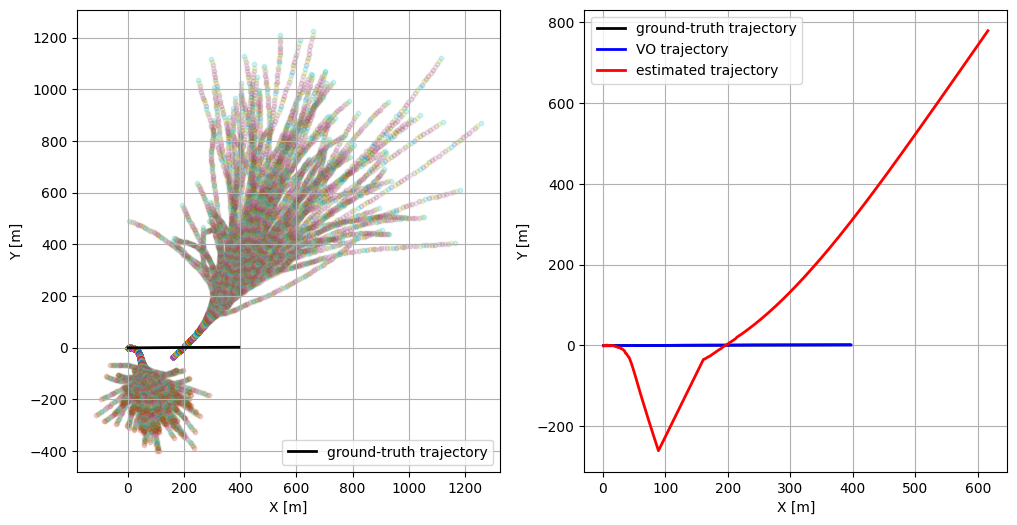

In [36]:
error_ekf1_30 = ekf1_30.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ukf1_30 = ukf1_30.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_pf1_30 = pf1_30.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    importance_resampling=importance_resampling,
    debug_mode=True,
    show_graph=True
)
error_enkf1_30 = enkf1_30.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ckf1_30 = ckf1_30.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT, 
    debug_mode=True
)

errors_30.append(error_ekf1_30)
errors_30.append(error_ukf1_30)
errors_30.append(error_pf1_30)
errors_30.append(error_enkf1_30)
errors_30.append(error_ckf1_30)

## Setup2

In [37]:
setup = SetupEnum.SETUP_2

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EKF, 
  noise_type=noise_type)
ekf2_30 = ExtendedKalmanFilter(
  x=x_setup2.copy(), 
  P=P_setup2.copy(), 
  H=H_setup2.copy(),
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup
)

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.UKF, 
  noise_type=noise_type)
ukf2_30 = UnscentedKalmanFilter(
    x=x_setup2.copy(), 
    P=P_setup2.copy(), 
    H=H_setup2.copy(), 
    q=q2,
    r_vo=r_vo2,
    r_gps=r_gps2,
    alpha=alpha_setup2_30, 
    beta=beta_setup2_30, 
    kappa=kappa_setup2_30,
    setup=setup
)

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.PF, 
  noise_type=noise_type)
pf2_30 = ParticleFilter(
  N=n_samples_setup2_30, 
  x_dim=x_setup2.shape[0], 
  H=H_setup2.copy(), 
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup,
  resampling_algorithm=resampling_algorithm_setup2_30
)
pf2_30.create_gaussian_particles(mean=x_setup2.copy(), var=P_setup2.copy())

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EnKF, 
  noise_type=noise_type)
enkf2_30 = EnsembleKalmanFilter(
  N=n_ensemble_setup2_30, 
  x=x_setup2.copy(), 
  P=P_setup2.copy(), 
  H=H_setup2.copy(),
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup
)

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.CKF, 
  noise_type=noise_type)
ckf2_30 = CubatureKalmanFilter(
  x=x_setup2.copy(), 
  P=P_setup2.copy(), 
  H=H_setup2.copy(),
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup,
)

In [38]:
error_ekf2_30 = ekf2_30.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ukf2_30 = ukf2_30.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_pf2_30 = pf2_30.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    importance_resampling=importance_resampling,
    debug_mode=True
)
error_enkf2_30 = enkf2_30.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ckf2_30 = ckf2_30.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT, 
    debug_mode=True
)

errors_30.append(error_ekf2_30)
errors_30.append(error_ukf2_30)
errors_30.append(error_pf2_30)
errors_30.append(error_enkf2_30)
errors_30.append(error_ckf2_30)

[EKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 9538.37it/s]



----- [EKF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 0.547 m
Root Mean Squared Error: 0.735 m
Maximum Error: 3.086 m
-------------------------------------------------------

[UKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 2100.57it/s]



----- [UKF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 0.836 m
Root Mean Squared Error: 1.127 m
Maximum Error: 5.827 m
-------------------------------------------------------

[PF] start.


...


----- [PF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 189.369 m
Root Mean Squared Error: 254.757 m
Maximum Error: 670.984 m
------------------------------------------------------

[EnKF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:04<00:00, 66.05it/s]



----- [EnKF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 1.132 m
Root Mean Squared Error: 1.461 m
Maximum Error: 5.375 m
--------------------------------------------------------

[CKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 2272.62it/s]


----- [CKF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 0.613 m
Root Mean Squared Error: 0.808 m
Maximum Error: 4.122 m
-------------------------------------------------------



## Setup3

In [39]:
setup = SetupEnum.SETUP_3

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EKF, 
  noise_type=noise_type)
ekf3_30 = ExtendedKalmanFilter(
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(),
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
)

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.UKF, 
  noise_type=noise_type)
ukf3_30 = UnscentedKalmanFilter(
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(), 
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  alpha=alpha_setup3_30, 
  beta=beta_setup3_30, 
  kappa=kappa_setup3_30,
  setup=setup,
)

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.PF, 
  noise_type=noise_type)
pf3_30 = ParticleFilter(
  N=n_samples_setup3_30, 
  x_dim=x_setup3.shape[0], 
  H=H_setup3.copy(), 
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
  resampling_algorithm=resampling_algorithm_setup3_30
)
pf3_30.create_gaussian_particles(mean=x_setup3.copy(), var=P_setup3.copy())

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EnKF, 
  noise_type=noise_type)
enkf3_30 = EnsembleKalmanFilter(
  N=n_ensemble_setup3_30, 
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(),
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
)

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.CKF, 
  noise_type=noise_type)
ckf3_30 = CubatureKalmanFilter(
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(),
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
)

In [40]:
error_ekf3_30 = ekf3_30.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ukf3_30 = ukf3_30.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_pf3_30 = pf3_30.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    importance_resampling=importance_resampling,
    debug_mode=True
)
error_enkf3_30 = enkf3_30.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ckf3_30 = ckf3_30.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT, 
    debug_mode=True,
)


errors_30.append(error_ekf3_30)
errors_30.append(error_ukf3_30)
errors_30.append(error_pf3_30)
errors_30.append(error_enkf3_30)
errors_30.append(error_ckf3_30)

[EKF] start.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 16705.94it/s]



----- [EKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 0.414 m
Root Mean Squared Error: 0.554 m
Maximum Error: 2.067 m
-----------------------------------------------

[UKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 6689.16it/s]



----- [UKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 0.525 m
Root Mean Squared Error: 0.694 m
Maximum Error: 2.904 m
-----------------------------------------------

[PF] start.


...


----- [PF] Error report for Setup3 (INS) -----
Mean Absolute Error: 0.397 m
Root Mean Squared Error: 0.55 m
Maximum Error: 2.231 m
----------------------------------------------

[EnKF] start.


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:01<00:00, 182.40it/s]



----- [EnKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 1.009 m
Root Mean Squared Error: 1.322 m
Maximum Error: 4.879 m
------------------------------------------------

[CKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 8631.57it/s]


----- [CKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 0.525 m
Root Mean Squared Error: 0.694 m
Maximum Error: 2.9 m
-----------------------------------------------



# 40% drop

In [41]:
data.change_dropout_ratio(vo_dropout_ratio=0.4, gps_dropout_ratio=0.4)

In [42]:
alpha_setup1_40 = 1.0
beta_setup1_40 = 2.0
kappa_setup1_40 = 0.0

alpha_setup2_40 = 1.0
beta_setup2_40 = 2.0
kappa_setup2_40 = 0.0

alpha_setup3_40 = 0.001
beta_setup3_40 = 2.0
kappa_setup3_40 = 0.0

n_samples_setup1_40 = 2048
resampling_algorithm_setup1_40 = ResamplingAlgorithms.SYSTEMATIC
n_samples_setup2_40 = 2048
resampling_algorithm_setup2_40 = ResamplingAlgorithms.SYSTEMATIC
n_samples_setup3_40 = 2048
resampling_algorithm_setup3_40 = ResamplingAlgorithms.MULTINOMIAL

n_ensemble_setup1_40 = 1024
n_ensemble_setup2_40 = 1024
n_ensemble_setup3_40 = 1024

## Setup1

In [43]:
setup = SetupEnum.SETUP_1

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EKF, 
  noise_type=noise_type)
ekf1_40 = ExtendedKalmanFilter(
  x=x_setup1.copy(), 
  P=P_setup1.copy(), 
  H=H_setup1.copy(),
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  setup=setup
)

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.UKF, 
  noise_type=noise_type)
ukf1_40 = UnscentedKalmanFilter(
  x=x_setup1.copy(), 
  P=P_setup1.copy(), 
  H=H_setup1.copy(), 
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  alpha=alpha_setup1_40, 
  beta=beta_setup1_40, 
  kappa=kappa_setup1_40,
  setup=setup
)

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.PF, 
  noise_type=noise_type)
pf1_40 = ParticleFilter(
  N=n_samples_setup1_40, 
  x_dim=x_setup1.shape[0], 
  H=H_setup1.copy(), 
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  setup=setup,
  resampling_algorithm=resampling_algorithm_setup1_40
)
pf1_40.create_gaussian_particles(mean=x_setup1.copy(), var=P_setup1.copy())

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EnKF, 
  noise_type=noise_type)
enkf1_40 = EnsembleKalmanFilter(
  N=n_ensemble_setup1_40, 
  x=x_setup1.copy(), 
  P=P_setup1.copy(), 
  H=H_setup1.copy(),
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  setup=setup
)

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.CKF, 
  noise_type=noise_type)
ckf1_40 = CubatureKalmanFilter(
    x=x_setup1.copy(), 
    P=P_setup1.copy(), 
    H=H_setup1.copy(),
    q=q1,
    r_vo=r_vo1,
    r_gps=r_gps1,
    setup=setup,
)

In [44]:
error_ekf1_40 = ekf1_40.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ukf1_40 = ukf1_40.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_pf1_40 = pf1_40.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT,
    importance_resampling=importance_resampling,
    debug_mode=True
)
error_enkf1_40 = enkf1_40.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ckf1_40 = ckf1_40.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT, 
    debug_mode=True,
)

errors_40.append(error_ekf1_40)
errors_40.append(error_ukf1_40)
errors_40.append(error_pf1_40)
errors_40.append(error_enkf1_40)
errors_40.append(error_ckf1_40)

[EKF] start.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 12157.14it/s]



----- [EKF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 0.867 m
Root Mean Squared Error: 1.176 m
Maximum Error: 6.951 m
---------------------------------------------------

[UKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 2680.29it/s]



----- [UKF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 2.64 m
Root Mean Squared Error: 3.358 m
Maximum Error: 11.484 m
---------------------------------------------------

[PF] start.


...


----- [PF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 160.601 m
Root Mean Squared Error: 233.82 m
Maximum Error: 660.293 m
--------------------------------------------------

[EnKF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:02<00:00, 97.71it/s]



----- [EnKF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 1.336 m
Root Mean Squared Error: 1.705 m
Maximum Error: 5.829 m
----------------------------------------------------

[CKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 1733.57it/s]


----- [CKF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 0.754 m
Root Mean Squared Error: 0.973 m
Maximum Error: 5.969 m
---------------------------------------------------



## Setup2

In [45]:
setup = SetupEnum.SETUP_2

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EKF, 
  noise_type=noise_type)
ekf2_40 = ExtendedKalmanFilter(
  x=x_setup2.copy(), 
  P=P_setup2.copy(), 
  H=H_setup2.copy(),
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup
)

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.UKF, 
  noise_type=noise_type)
ukf2_40 = UnscentedKalmanFilter(
    x=x_setup2.copy(), 
    P=P_setup2.copy(), 
    H=H_setup2.copy(), 
    q=q2,
    r_vo=r_vo2,
    r_gps=r_gps2,
    alpha=alpha_setup2_40, 
    beta=beta_setup2_40, 
    kappa=kappa_setup2_40,
    setup=setup
)

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.PF, 
  noise_type=noise_type)
pf2_40 = ParticleFilter(
  N=n_samples_setup2_40, 
  x_dim=x_setup2.shape[0], 
  H=H_setup2.copy(), 
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup,
  resampling_algorithm=resampling_algorithm_setup2_40
)
pf2_40.create_gaussian_particles(mean=x_setup2.copy(), var=P_setup2.copy())

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EnKF, 
  noise_type=noise_type)
enkf2_40 = EnsembleKalmanFilter(
  N=n_ensemble_setup2_40, 
  x=x_setup2.copy(), 
  P=P_setup2.copy(), 
  H=H_setup2.copy(),
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup
)

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.CKF, 
  noise_type=noise_type)
ckf2_40 = CubatureKalmanFilter(
  x=x_setup2.copy(), 
  P=P_setup2.copy(), 
  H=H_setup2.copy(),
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup,
)

In [46]:
error_ekf2_40 = ekf2_40.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ukf2_40 = ukf2_40.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_pf2_40 = pf2_40.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT,
    importance_resampling=importance_resampling,
    debug_mode=True
)
error_enkf2_40 = enkf2_40.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ckf2_40 = ckf2_40.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT, 
    debug_mode=True
)


errors_40.append(error_ekf2_40)
errors_40.append(error_ukf2_40)
errors_40.append(error_pf2_40)
errors_40.append(error_enkf2_40)
errors_40.append(error_ckf2_40)

[EKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 4609.22it/s]



----- [EKF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 0.583 m
Root Mean Squared Error: 0.756 m
Maximum Error: 3.294 m
-------------------------------------------------------

[UKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 2052.39it/s]



----- [UKF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 1.05 m
Root Mean Squared Error: 1.362 m
Maximum Error: 5.556 m
-------------------------------------------------------

[PF] start.


...


----- [PF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 0.881 m
Root Mean Squared Error: 1.236 m
Maximum Error: 5.563 m
------------------------------------------------------

[EnKF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:03<00:00, 78.20it/s]



----- [EnKF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 1.128 m
Root Mean Squared Error: 1.434 m
Maximum Error: 5.225 m
--------------------------------------------------------

[CKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 2202.55it/s]


----- [CKF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 0.641 m
Root Mean Squared Error: 0.831 m
Maximum Error: 3.727 m
-------------------------------------------------------



## Setup3

In [47]:
setup = SetupEnum.SETUP_3

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EKF, 
  noise_type=noise_type)
ekf3_40 = ExtendedKalmanFilter(
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(),
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
)

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.UKF, 
  noise_type=noise_type)
ukf3_40 = UnscentedKalmanFilter(
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(), 
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  alpha=alpha_setup3_40, 
  beta=beta_setup3_40, 
  kappa=kappa_setup3_40,
  setup=setup,
)

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.PF, 
  noise_type=noise_type)
pf3_40 = ParticleFilter(
  N=n_samples_setup3_40, 
  x_dim=x_setup3.shape[0], 
  H=H_setup3.copy(), 
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
  resampling_algorithm=resampling_algorithm_setup3_40
)
pf3_40.create_gaussian_particles(mean=x_setup3.copy(), var=P_setup3.copy())

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EnKF, 
  noise_type=noise_type)
enkf3_40 = EnsembleKalmanFilter(
  N=n_ensemble_setup3_40, 
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(),
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
)

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.CKF, 
  noise_type=noise_type)
ckf3_40 = CubatureKalmanFilter(
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(),
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
)

In [48]:
error_ekf3_40 = ekf3_40.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ukf3_40 = ukf3_40.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_pf3_40 = pf3_40.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT,
    importance_resampling=importance_resampling,
    debug_mode=True
)
error_enkf3_40 = enkf3_40.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ckf3_40 = ckf3_40.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT, 
    debug_mode=True
)


errors_40.append(error_ekf3_40)
errors_40.append(error_ukf3_40)
errors_40.append(error_pf3_40)
errors_40.append(error_enkf3_40)
errors_40.append(error_ckf3_40)

[EKF] start.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 18614.69it/s]



----- [EKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 0.415 m
Root Mean Squared Error: 0.548 m
Maximum Error: 2.038 m
-----------------------------------------------

[UKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 7284.92it/s]



----- [UKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 0.538 m
Root Mean Squared Error: 0.704 m
Maximum Error: 3.024 m
-----------------------------------------------

[PF] start.


...


----- [PF] Error report for Setup3 (INS) -----
Mean Absolute Error: 0.421 m
Root Mean Squared Error: 0.584 m
Maximum Error: 2.422 m
----------------------------------------------

[EnKF] start.


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:01<00:00, 216.02it/s]



----- [EnKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 1.003 m
Root Mean Squared Error: 1.294 m
Maximum Error: 4.435 m
------------------------------------------------

[CKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 7737.19it/s]


----- [CKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 0.538 m
Root Mean Squared Error: 0.704 m
Maximum Error: 3.019 m
-----------------------------------------------



# Results

In [49]:
mae_df, rmse_df, max_df = get_error_dataframe(errors_0, errors_10, errors_20, errors_30, errors_40)

In [50]:
mae_df

Setups       Setup1 (IMU, VO)                                \
Filter types              EKF    UKF       PF   EnKF    CKF   
No dropout              0.726  0.872  119.641  1.188  0.746   
10% drop                0.772  1.585  109.939  1.226  0.766   
20% drop                0.828  1.493  149.597  1.251  0.776   
30% drop                0.860  2.268  152.263  1.315  0.801   
40% drop                0.867  2.640  160.601  1.336  0.754   

Setups       Setup2(IMU, VO+GPS)                                \
Filter types                 EKF    UKF       PF   EnKF    CKF   
No dropout                 0.515  0.657  163.181  1.030  0.609   
10% drop                   0.536  0.683    0.795  1.052  0.617   
20% drop                   0.548  0.757    0.789  1.064  0.630   
30% drop                   0.547  0.836  189.369  1.132  0.613   
40% drop                   0.583  1.050    0.881  1.128  0.641   

Setups       Setup3(INS, VO+INS)                              
Filter types                 EKF    UKF     PF   EnKF    CKF  
No dropout                 0.383  0.521  0.352  0.947  0.521  
10% drop                   0.383  0.524  0.383  0.978  0.524  
20% drop                   0.423  0.541  0.385  0.972  0.541  
30% drop                   0.414  0.525  0.397  1.009  0.525  
40% drop                   0.415  0.538  0.421  1.003  0.538

In [51]:
rmse_df

Setups       Setup1 (IMU, VO)                                \
Filter types              EKF    UKF       PF   EnKF    CKF   
No dropout              0.976  1.148  177.710  1.517  0.969   
10% drop                1.035  2.043  172.539  1.571  1.010   
20% drop                1.080  1.944  208.055  1.617  1.014   
30% drop                1.130  2.881  235.399  1.714  1.027   
40% drop                1.176  3.358  233.820  1.705  0.973   

Setups       Setup2(IMU, VO+GPS)                                \
Filter types                 EKF    UKF       PF   EnKF    CKF   
No dropout                 0.679  0.836  237.902  1.295  0.783   
10% drop                   0.710  0.855    1.193  1.336  0.792   
20% drop                   0.720  0.994    1.243  1.366  0.812   
30% drop                   0.735  1.127  254.757  1.461  0.808   
40% drop                   0.756  1.362    1.236  1.434  0.831   

Setups       Setup3(INS, VO+INS)                              
Filter types                 EKF    UKF     PF   EnKF    CKF  
No dropout                 0.503  0.671  0.490  1.210  0.671  
10% drop                   0.506  0.675  0.512  1.244  0.675  
20% drop                   0.552  0.698  0.520  1.248  0.698  
30% drop                   0.554  0.694  0.550  1.322  0.694  
40% drop                   0.548  0.704  0.584  1.294  0.704

In [52]:
max_df

Setups       Setup1 (IMU, VO)                                 \
Filter types              EKF     UKF       PF   EnKF    CKF   
No dropout              3.631   4.154  598.789  5.966  3.750   
10% drop                3.809   7.892  524.354  5.860  3.743   
20% drop                4.058   7.671  538.508  6.108  3.687   
30% drop                4.379  10.218  777.292  7.394  3.251   
40% drop                6.951  11.484  660.293  5.829  5.969   

Setups       Setup2(IMU, VO+GPS)                                \
Filter types                 EKF    UKF       PF   EnKF    CKF   
No dropout                 3.020  3.315  764.408  4.760  3.865   
10% drop                   3.540  2.841    5.861  6.376  3.476   
20% drop                   3.540  4.501    6.438  4.427  3.755   
30% drop                   3.086  5.827  670.984  5.375  4.122   
40% drop                   3.294  5.556    5.563  5.225  3.727   

Setups       Setup3(INS, VO+INS)                              
Filter types                 EKF    UKF     PF   EnKF    CKF  
No dropout                 1.614  2.944  1.862  3.459  2.941  
10% drop                   1.617  2.582  1.885  4.468  2.579  
20% drop                   1.815  3.030  2.372  4.418  3.027  
30% drop                   2.067  2.904  2.231  4.879  2.900  
40% drop                   2.038  3.024  2.422  4.435  3.019

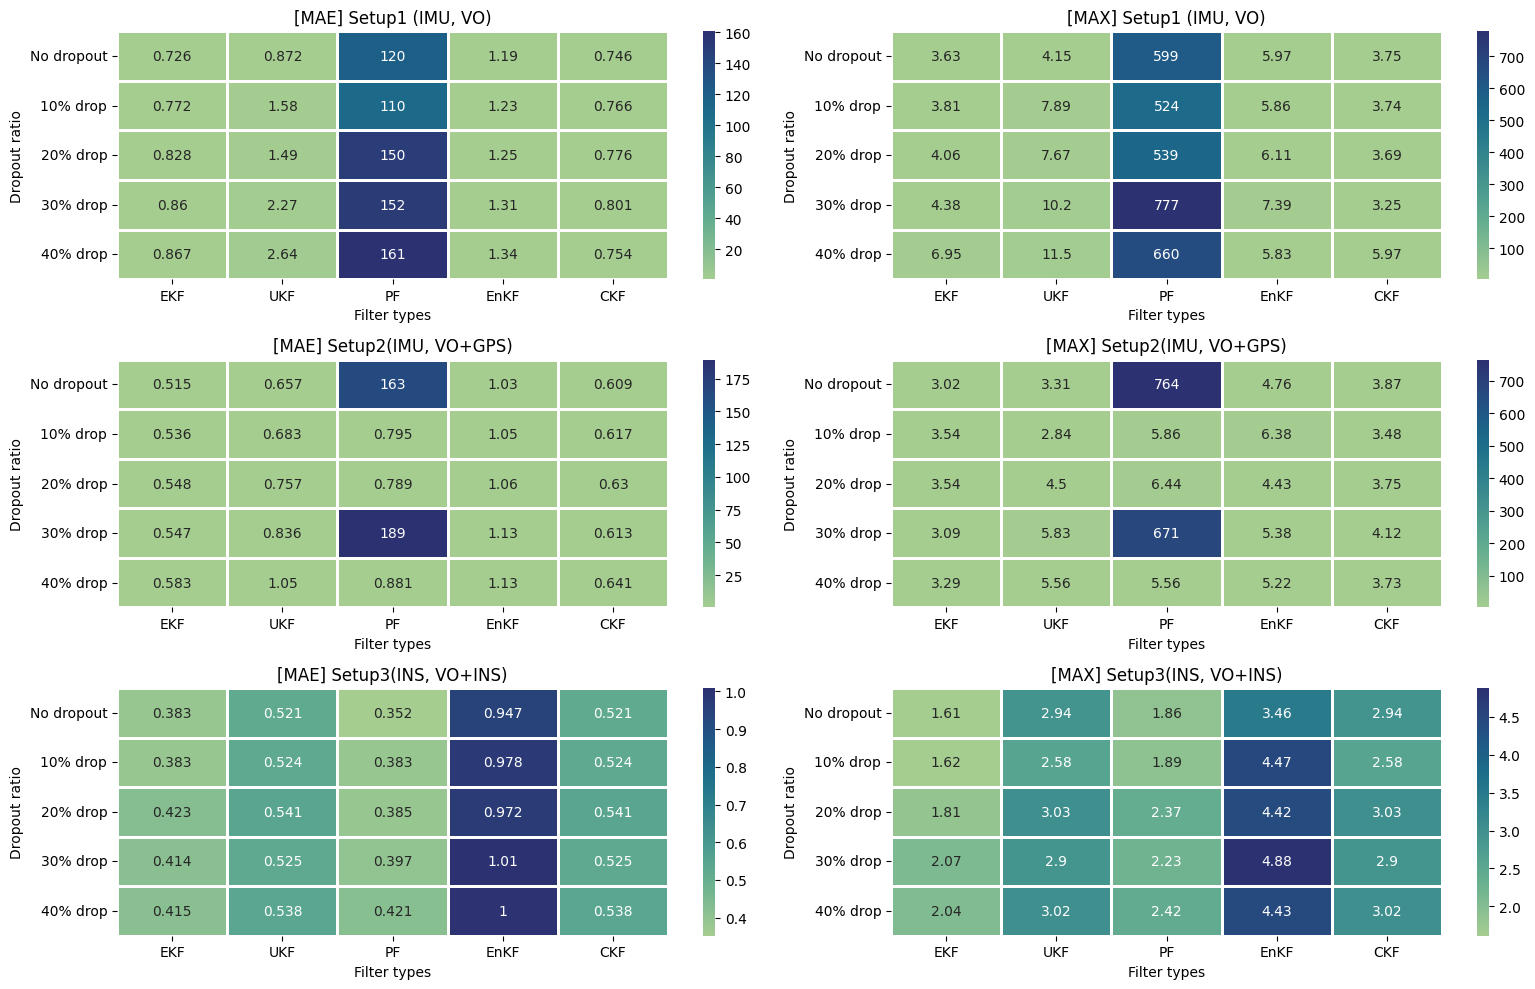

In [53]:
fig, (ax1_, ax2_, ax3_) = plt.subplots(nrows=3, ncols=2, figsize=(16, 10))
ax1, ax2 = ax1_[0], ax1_[1]
ax3, ax4 = ax2_[0], ax2_[1]
ax5, ax6 = ax3_[0], ax3_[1]

sns.heatmap(mae_df["Setup1 (IMU, VO)"],
            ax=ax1,
            cmap="crest",
            annot=True,
            linewidths=1,
            fmt='.3g')
ax1.set_title("[MAE] Setup1 (IMU, VO)")
ax1.set(xlabel="Filter types", ylabel="Dropout ratio")

sns.heatmap(mae_df["Setup2(IMU, VO+GPS)"],
            ax=ax3,
            cmap="crest",
            annot=True,
            linewidths=1,
            fmt='.3g')
ax3.set_title("[MAE] Setup2(IMU, VO+GPS)")
ax3.set(xlabel="Filter types", ylabel="Dropout ratio")

sns.heatmap(mae_df["Setup3(INS, VO+INS)"],
            ax=ax5,
            cmap="crest",
            annot=True,
            linewidths=1,
            fmt='.3g')
ax5.set_title("[MAE] Setup3(INS, VO+INS)")
ax5.set(xlabel="Filter types", ylabel="Dropout ratio")

sns.heatmap(max_df["Setup1 (IMU, VO)"],
            ax=ax2,
            cmap="crest",
            annot=True,
            linewidths=1,
            fmt='.3g')
ax2.set_title("[MAX] Setup1 (IMU, VO)")
ax2.set(xlabel="Filter types", ylabel="Dropout ratio")

sns.heatmap(max_df["Setup2(IMU, VO+GPS)"],
            ax=ax4,
            cmap="crest",
            annot=True,
            linewidths=1,
            fmt='.3g')
ax4.set_title("[MAX] Setup2(IMU, VO+GPS)")
ax4.set(xlabel="Filter types", ylabel="Dropout ratio")

sns.heatmap(max_df["Setup3(INS, VO+INS)"],
            ax=ax6,
            cmap="crest",
            annot=True,
            linewidths=1,
            fmt='.3g')
ax6.set_title("[MAX] Setup3(INS, VO+INS)")
ax6.set(xlabel="Filter types", ylabel="Dropout ratio")

fig.tight_layout()

In [54]:
mae_df.to_json(os.path.join(file_export_path, "pf_guaranteed_mae_df.json"))
rmse_df.to_json(os.path.join(file_export_path, "pf_guaranteed_rmse_df.json"))
max_df.to_json(os.path.join(file_export_path, "pf_guaranteed_max_df.json"))

# Conclusion

In this notebook, Kitti dataset sequeence number 4 is utilized to test all the implemented filters. Moreover, all the filters are tested for each setup with respect to measurement dropout ratio. To avoid filter divergence, particle filter has 2048 particles to approximate the posterior density.

In the setup 1, where IMU control input and VO measurement data are used, EKF provides the best result in MAE. However, the maximum error growth with respect the increase of dropout ratio of the Particle filter is les than the other filters and the difference of MAE between EKF and PF is negligible. Therefore, PF is the best result acheived in this setup.

In the setup 2, where IMU control input, VO and GPS measurement data are used, similar to the setup 1, PF has less growth of maximum error with respect to increase of dropout ratio in measurement data, PF has the best result than the other filters. 

In the setup 3, where INS control input and VO and INS measurement data are used, EKF outputs the best result in both MAE and maximum error in the trajectory.

The trajectory of the Kitti dataset sequence number 4 is straight line, in which the small amount of rotation is observed. Therefore, EKF's the first-order approximation on the systems model is strong enough the express the posterior density of the system, resulting in EKF performs well in this dataset.